## Proyecto Fashion-MNIST

In [9]:
# PyTorch Modules you need for this lab

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
torch.manual_seed(0)

Importa Módulos No-Pytorch

In [10]:
# Other non-PyTorch Modules

from matplotlib.pyplot import imshow
import matplotlib.pylab as plt

from PIL import Image

In [11]:
def show_data(data_sample):
    plt.imshow(data_sample[0].numpy().reshape(IMAGE_SIZE, IMAGE_SIZE), cmap='gray')
    plt.title('y = '+ str(data_sample[1]))

## Crea una clase Dataset
En esta sección, cargarás un objeto Dataset, pero primero debes transformar el conjunto de datos. Usa la función `Compose` para realizar las siguientes transformaciones:

<ol>
    <li>Usar el objeto transforms con `Resize` para redimensionar la imagen.</li>
    <li>Usar el objeto transforms con `ToTensor` para convertir la imagen en un tensor.</li>
</ol>

Luego, deberás tomar una captura de pantalla de tus datos de validación.


Usar la función Compose para combinar las transformaciones.

In [12]:
#Hint:

IMAGE_SIZE = 16

transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
transforms.ToTensor()#
composed = transforms.Compose([transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), transforms.ToTensor()])

Crear dos objetos de dataset para el conjunto de datos **Fashion-MNIST**.

* Uno para los datos de entrenamiento, llamado `dataset_train`.
* Otro para los datos de validación, llamado `dataset_val`.


In [13]:
dataset_train = dsets.FashionMNIST(root='./fashion/data', train=True, transform=composed, download=True)
dataset_val = dsets.FashionMNIST(root='./fashion/data', train=False, transform=composed, download=True)

# Verificar que se crearon correctamente
print(f"Training samples: {len(dataset_train)}")
print(f"Validation samples: {len(dataset_val)}")
dataset_train = dsets.FashionMNIST(root='./fashion/data', train=True, transform=composed, download=True)
dataset_val = dsets.FashionMNIST(root='./fashion/data', train=False, transform=composed, download=True)

100.0%
100.0%
100.0%
100.0%

Training samples: 60000
Validation samples: 10000


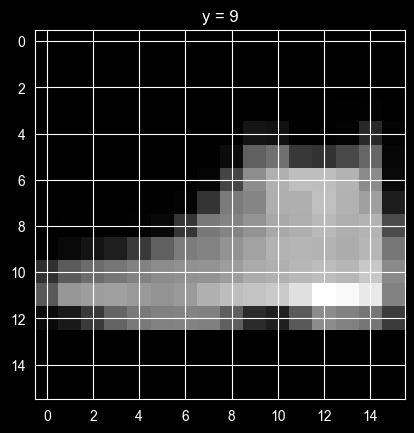

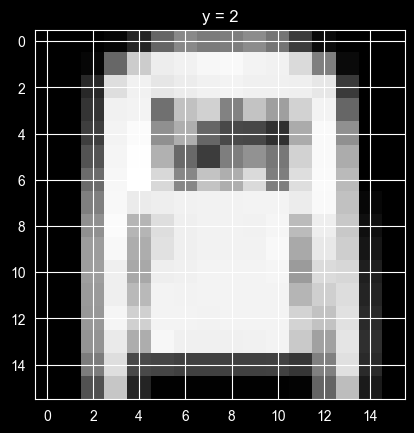

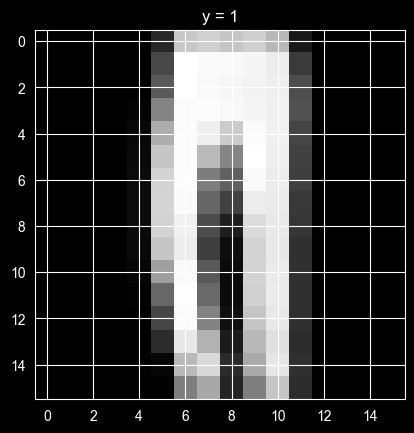

In [14]:
for n,data_sample in enumerate(dataset_val):

    show_data(data_sample)
    plt.show()
    if n==2:
        break

<a name="Q2"><h2 id="Q2">Preguntas 2</h2></a>
Crear una **clase de Red Neuronal Convolucional** usando **UNO de los constructores siguientes**. Entrena la red usando el **código proporcionado** y luego proporciona una **captura de pantalla del costo de entrenamiento y la precisión** con tus **datos de validación**.


In [15]:
class CNN_batch(nn.Module):

    # Constructor
    def __init__(self, out_1=16, out_2=32,number_of_classes=10):
        super(CNN_batch, self).__init__()
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=out_1, kernel_size=5, padding=2)
        self.conv1_bn = nn.BatchNorm2d(out_1)

        self.maxpool1=nn.MaxPool2d(kernel_size=2)

        self.cnn2 = nn.Conv2d(in_channels=out_1, out_channels=out_2, kernel_size=5, stride=1, padding=2)
        self.conv2_bn = nn.BatchNorm2d(out_2)

        self.maxpool2=nn.MaxPool2d(kernel_size=2)
        self.fc1 = nn.Linear(out_2 * 4 * 4, number_of_classes)
        self.bn_fc1 = nn.BatchNorm1d(10)

    # Prediction
    def forward(self, x):
        x = self.cnn1(x)
        x=self.conv1_bn(x)
        x = torch.relu(x)
        x = self.maxpool1(x)
        x = self.cnn2(x)
        x=self.conv2_bn(x)
        x = torch.relu(x)
        x = self.maxpool2(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x=self.bn_fc1(x)
        return x

Constructor para una Red Neuronal Convolucional regular

In [16]:
class CNN(nn.Module):

    # Constructor
    def __init__(self, out_1=16, out_2=32,number_of_classes=10):
        super(CNN, self).__init__()
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=out_1, kernel_size=5, padding=2)
        self.maxpool1=nn.MaxPool2d(kernel_size=2)

        self.cnn2 = nn.Conv2d(in_channels=out_1, out_channels=out_2, kernel_size=5, stride=1, padding=2)
        self.maxpool2=nn.MaxPool2d(kernel_size=2)
        self.fc1 = nn.Linear(out_2 * 4 * 4, number_of_classes)

    # Prediction
    def forward(self, x):
        x = self.cnn1(x)
        x = torch.relu(x)
        x = self.maxpool1(x)
        x = self.cnn2(x)
        x = torch.relu(x)
        x = self.maxpool2(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

**Cargador de entrenamiento** (`train loader`) y **cargador de validación** (`validation loader`).

In [17]:
train_loader = torch.utils.data.DataLoader(dataset=dataset_train, batch_size=100 )
test_loader = torch.utils.data.DataLoader(dataset=dataset_val, batch_size=100 )

Objeto de Red Neuronal Convolucional

In [ ]:
#model = CNN(out_1=16, out_2=32,number_of_classes=10)
#model =CNN_batch(out_1=16, out_2=32,number_of_classes=10)

Crea los objetos para la función de pérdida y el optimizador, llamados `criterion` y `optimizer`.

* El optimizador** debe usar SGD con una tasa de aprendizaje de 0.1.
* La función de pérdida debe usar Cross Entropy Loss.


In [18]:
# Enter your code here
model = CNN_batch(out_1=16, out_2=32, number_of_classes=10)

# Create criterion (loss function)
criterion = nn.CrossEntropyLoss()

# Create optimizer with learning rate 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

Code used to train the model

In [19]:
import time
start_time = time.time()

cost_list=[]
accuracy_list=[]
N_test=len(dataset_val)
n_epochs=5
for epoch in range(n_epochs):
    cost=0
    model.train()
    for x, y in train_loader:
        optimizer.zero_grad()
        z = model(x)
        loss = criterion(z, y)
        loss.backward()
        optimizer.step()
        cost+=loss.item()
    correct=0
    #perform a prediction on the validation  data
    model.eval()
    for x_test, y_test in test_loader:
        z = model(x_test)
        _, yhat = torch.max(z.data, 1)
        correct += (yhat == y_test).sum().item()
    accuracy = correct / N_test
    accuracy_list.append(accuracy)
    cost_list.append(cost)

    print(f'Epoch: {epoch+1}/{n_epochs}, Cost: {cost:.4f}, Accuracy: {accuracy:.4f}')

print(f"Training time: {time.time()-start_time:.2f} seconds")

Epoch: 1/5, Cost: 297.4408, Accuracy: 0.8682
Epoch: 2/5, Cost: 206.4808, Accuracy: 0.8763
Epoch: 3/5, Cost: 185.2457, Accuracy: 0.8811
Epoch: 4/5, Cost: 172.1728, Accuracy: 0.8848
Epoch: 5/5, Cost: 162.3714, Accuracy: 0.8865
Training time: 43.79 seconds


Usar lo siguiente para graficar el costo y la precisión de cada época para los datos de entrenamiento y prueba, respectivamente.

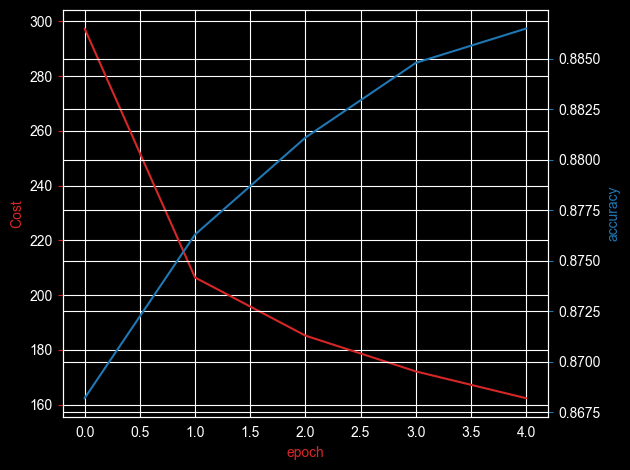

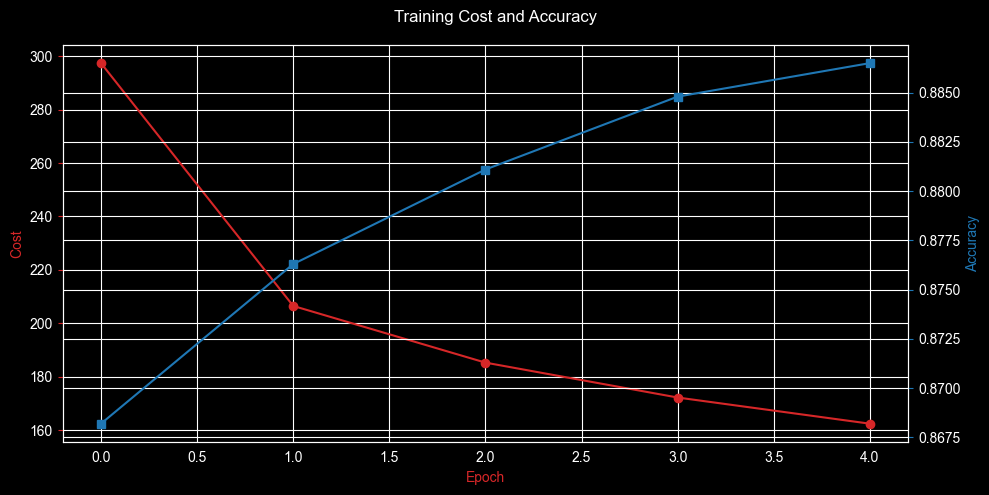

In [20]:
fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.plot(cost_list, color=color)
ax1.set_xlabel('epoch', color=color)
ax1.set_ylabel('Cost', color=color)
ax1.tick_params(axis='y', color=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('accuracy', color=color)
ax2.set_xlabel('epoch', color=color)
ax2.plot( accuracy_list, color=color)
ax2.tick_params(axis='y', color=color)
fig.tight_layout()

# Plot cost and accuracy
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.plot(cost_list, color=color, marker='o', label='Cost')
ax1.set_xlabel('Epoch', color=color)
ax1.set_ylabel('Cost', color=color)
ax1.tick_params(axis='y', color=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.plot(accuracy_list, color=color, marker='s', label='Accuracy')
ax2.set_ylabel('Accuracy', color=color)
ax2.tick_params(axis='y', color=color)

fig.suptitle('Training Cost and Accuracy')
fig.tight_layout()
plt.show()

dataset: https://github.com/zalandoresearch/fashion-mnist